# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Endang Suhendar
- **Email:** endang.s@mhs.unsoed.ac.id - cdcc229d6y2242@student.devacademy.id
- **ID Dicoding:** CDCC229D6Y2242

## Menentukan Pertanyaan Bisnis

- Bagaimana perbedaan rata-rata jumlah peminjaman sepeda antara hari kerja dan akhir pekan selama tahun 2011–2012, serta bagaimana perbedaannya antar tahun tersebut?
- Bagaimana hubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2011–2012 berdasarkan analisis korelasi?

## Import Semua Packages/Library yang Digunakan

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

In [46]:
#Memuat Tabel
df = pd.read_csv('day.csv')
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**
- Data si atas diambil dari file "day.csv" yang dibaca menggunakan fungsi read_csv() dari library pandas.
- Di dalam dataset tersebut memiliki beberapa kolom diantaranya instant, dteday, season, yr, mnth, holiday, weekday, workingday, weathersit, temp, atemp, hum, windspeed, casual, registered, dan cnt.

### Assessing Data

In [47]:
# Menilai Data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


**Insight:**
- Dataset di atas memiliki 16 kolom dengan tipe data yang beragam yaitu integer, object, dan float.

In [48]:
# Cek Missing Value
df.isnull().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


**Insight:**
- Dataset di atas tidak memiliki missing value.

In [49]:
# Cek Duplikasi data
df.duplicated().sum()

np.int64(0)

**Insight:**
- Dataset di atas tidak memiliki duplikasi data.

In [50]:
# Statistika Deskriptif
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Insight:**

Berdasarkan hasil statistika deskriptif didapat:
- Rata-rata nilai workingday adalah 0,683995 yang menunjukkan bahwa sekitar 68% digunakan pada workingday dan sisanya yaitu sekitar 32% digunakan pada weekend atau holiday.
- Rata-rata peminjaman sepeda adalah sebesar 4504,348837 per hari, dengan nilai minimum 22 dan maksimum 8714.
- Rentang nilai suhu yaitu diantara 0,059130 - 0,861667 dengan rata-rata 0,495385 dan rentang nilai keelembapan diantara 0 - 0,972500 dengan rata-rata 0,627894/

### Cleaning Data

In [51]:
# Mengubah Tipe Data
df['dteday'] = pd.to_datetime(df['dteday'])

**Insight:**
- Mengubah tibe data dteday yang tadinya object menjadi datetime agar sesuai dengan kegunaannya.

In [52]:
# Mengubah Nilai Kategori
df['season'] = df['season'].map({1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'})
df['weathersit'] = df['weathersit'].map({1:'Clear', 2:'Mist', 3:'Light Rain', 4:'Heavy Rain'})
df['workingday'] = df['workingday'].map({0:'Weekend', 1:'Working Day'})

**Insight:**
- Mengubah nilai kategori menjadi nilai numerik agar lebih mudah pada saat analisis ataupun visualisasi.

In [53]:
# Cek Ulang Data
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    object        
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    object        
 8   weathersit  731 non-null    object        
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,Spring,0,1,0,6,Weekend,Mist,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,Spring,0,1,0,0,Weekend,Mist,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,Spring,0,1,0,1,Working Day,Clear,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,Spring,0,1,0,2,Working Day,Clear,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,Spring,0,1,0,3,Working Day,Clear,0.226957,0.229270,0.436957,0.186900,82,1518,1600


**Insight:**

Dapat dilihat bahwa data telah berubah sesuai yang diinginkan.

## Exploratory Data Analysis (EDA)

### Explore Data

In [77]:
# Pertanyaan 1

# Rata-rata jumlah peminjaman sepeda pada tahun 2011
df_2011 = df[df['dteday'].dt.year == 2011]
avg_2011 = df_2011.groupby('workingday')['cnt'].mean()
print("Rata-rata jumlah peminjaman sepeda pada tahun 2011:")
print(avg_2011)

# Rata-rata jumlah peminjaman sepeda pada tahun 2012
df_2012 = df[df['dteday'].dt.year == 2012]
avg_2012 = df_2012.groupby('workingday')['cnt'].mean()
print("\nRata-rata jumlah peminjaman sepeda pada tahun 2012:")
print(avg_2012)

Rata-rata jumlah peminjaman sepeda pada tahun 2011:
workingday
Weekend        3363.817391
Working Day    3425.056000
Name: cnt, dtype: float64

Rata-rata jumlah peminjaman sepeda pada tahun 2012:
workingday
Weekend        5288.189655
Working Day    5744.584000
Name: cnt, dtype: float64


**Insight:**

Berdasarkan hasil analisis:
- Pada tahun 2011 rata-rata jumlah peminjaman sepeda pada akhir pekan adalah 3363,82 sedangkan pada hari kerja sebesar 3425,06. Perbedaan ini relatif kecil, menunjukkan bahwa pada tahun tersebut pola penggunaan sepeda antara hari kerja dan akhir pekan masih cenderung seimbang.
- Pada tahun 2012 terjadi peningkatan yang cukup signifikan pada kedua kategori, di mana rata-rata peminjaman pada akhir pekan meningkat menjadi 5288,19 dan pada hari kerja meningkat menjadi 5744,58. Selain mengalami kenaikan jumlah peminjaman secara keseluruhan, selisih antara hari kerja dan akhir pekan juga menjadi lebih besar dibanding tahun 2011. Hal ini menunjukkan bahwa pada tahun 2012 terjadi peningkatan penggunaan sepeda secara umum, dengan kecenderungan yang lebih kuat pada hari kerja, yang mengindikasikan bahwa sepeda semakin banyak digunakan sebagai sarana transportasi rutin seperti aktivitas bekerja atau bersekolah

In [78]:
# Pertanyaan 2

# Hubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2011
corr_2011 = df_2011[['temp','hum','cnt']].corr()
print("Hubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2011:")
print(corr_2011)

# Hubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2012
corr_2012 = df_2012[['temp','hum','cnt']].corr()
print("\nHubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2012:")
print(corr_2012)

Hubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2011:
          temp       hum       cnt
temp  1.000000  0.145776  0.771214
hum   0.145776  1.000000  0.001898
cnt   0.771214  0.001898  1.000000

Hubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2012:
          temp       hum       cnt
temp  1.000000  0.118262  0.713793
hum   0.118262  1.000000 -0.088861
cnt   0.713793 -0.088861  1.000000


**Insight:**

Berdasarkan hasil analisis:
- Pada tahun 2011 suhu memiliki hubungan positif yang cukup kuat dengan jumlah peminjaman sepeda dengan nilai korelasi sebesar 0,771214. Hal ini menunjukkan bahwa semakin tinggi suhu, maka jumlah peminjaman sepeda cenderung meningkat. Sementara itu, kelembapan memiliki hubungan yang sangat lemah dengan jumlah peminjaman sepeda, dengan nilai korelasi mendekati nol yaitu 0,001898, yang berarti kelembapan hampir tidak berpengaruh pada tahun tersebut.
- Pada tahun 2012, pola yang serupa masih terlihat, di mana suhu tetap memiliki hubungan positif yang cukup kuat dengan jumlah peminjaman sepeda yaitu sebesar 0,713793, meskipun sedikit menurun dibandingkan tahun 2011. Sebaliknya, kelembapan menunjukkan korelasi negatif yang sangat lemah yaitu sebesar -0,088861), yang mengindikasikan bahwa peningkatan kelembapan sedikit cenderung diikuti oleh penurunan jumlah peminjaman, meskipun pengaruhnya tidak signifikan.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

/tmp/ipykernel_6103/634484662.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


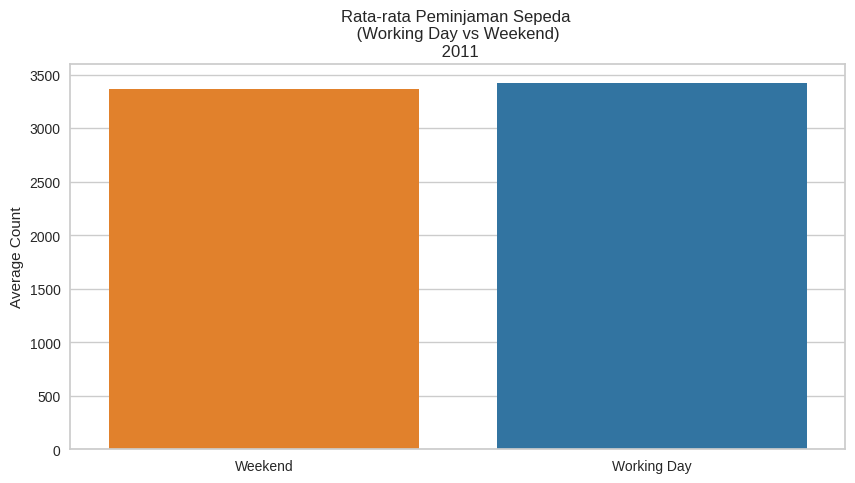

/tmp/ipykernel_6103/634484662.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


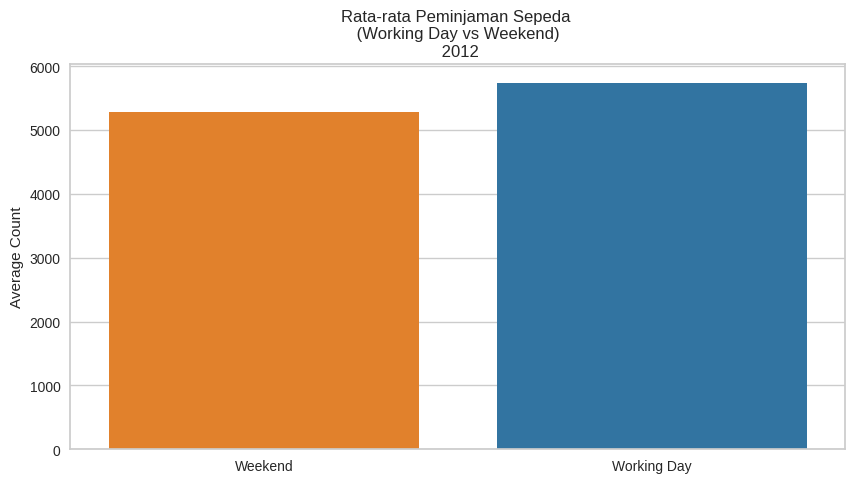

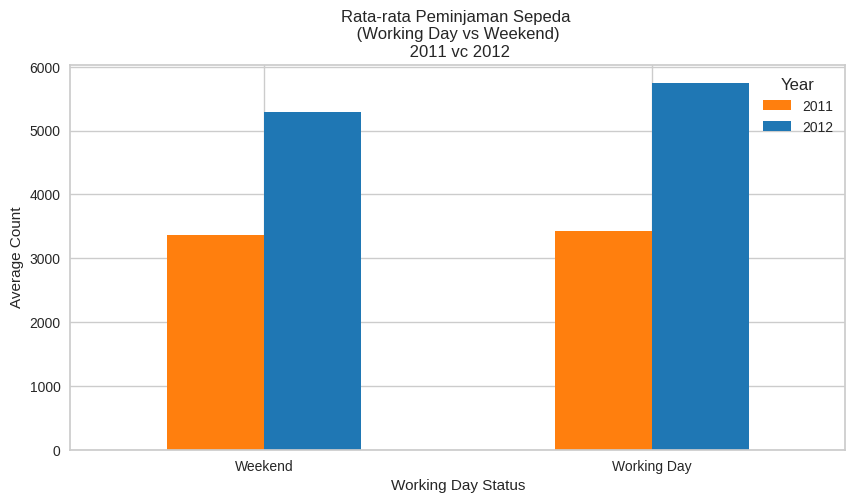

In [89]:

# Visualisasi rata-rata jumlah peminjaman sepeda pada tahun 2011
avg_2011 = df_2011.groupby('workingday')['cnt'].mean()

plt.figure(figsize=(10,5))
sns.barplot(
    x=avg_2011.index,
    y=avg_2011.values,
    palette=['#ff7f0e', '#1f77b4']
)

plt.title('Rata-rata Peminjaman Sepeda \n (Working Day vs Weekend) \n 2011')
plt.ylabel('Average Count')
plt.xlabel('')
plt.show()

# Visualisasi rata-rata jumlah peminjaman sepeda pada tahun 2011
avg_2012 = df_2012.groupby('workingday')['cnt'].mean()

plt.figure(figsize=(10,5))
sns.barplot(
    x=avg_2012.index,
    y=avg_2012.values,
    palette=['#ff7f0e', '#1f77b4']
)

plt.title('Rata-rata Peminjaman Sepeda \n (Working Day vs Weekend) \n 2012')
plt.ylabel('Average Count')
plt.xlabel('')
plt.show()

# Visualisasi rata-rata peminjaman Sepeda pada Working Day vs Weekend di tahun 2011 - 2012
avg_compare = pd.DataFrame({
    '2011': avg_2011,
    '2012': avg_2012
})

ax = avg_compare.plot(
    kind='bar',
    figsize=(10,5),
    color=['#ff7f0e', '#1f77b4']
)

plt.title('Rata-rata Peminjaman Sepeda \n (Working Day vs Weekend) \n 2011 vc 2012')
plt.ylabel('Average Count')
plt.xlabel('Working Day Status')
plt.xticks(rotation=0)
plt.legend(title='Year')

plt.show()

### Pertanyaan 2:

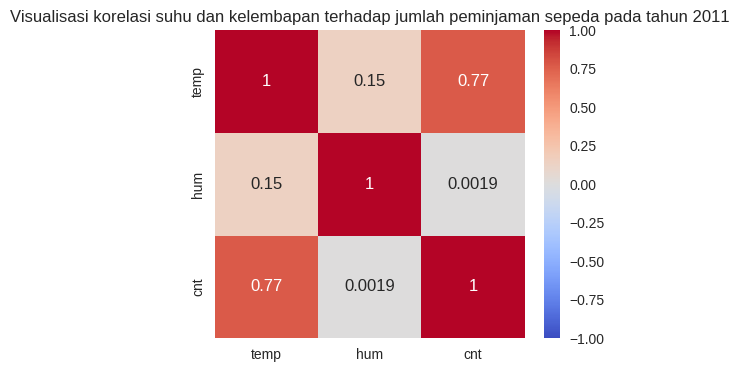

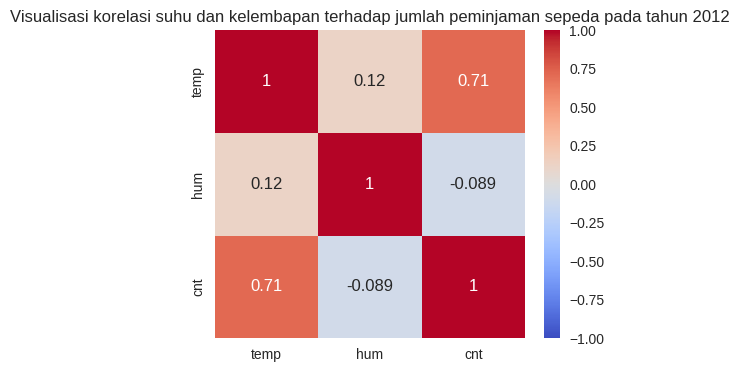

In [90]:
# Korelasi suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2011
corr_2011 = df_2011[['temp', 'hum', 'cnt']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_2011, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Visualisasi korelasi suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2011')
plt.show()

# Hubungan suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2012
corr_2012 = df_2012[['temp', 'hum', 'cnt']].corr()

plt.figure(figsize=(5,4))
sns.heatmap(corr_2012, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Visualisasi korelasi suhu dan kelembapan terhadap jumlah peminjaman sepeda pada tahun 2012')
plt.show()

**Insight:**
- Terjadi peningkatan jumlah peminjaman sepeda dari tahun 2011 ke 2012 pada baik hari kerja maupun akhir pekan. Hari kerja selalu memiliki rata-rata peminjaman yang lebih tinggi dibandingkan akhir pekan, dan selisihnya semakin besar di tahun 2012.
- Suhu memiliki hubungan positif yang cukup kuat terhadap jumlah peminjaman sepeda pada tahun 2011 dan 2012, yang berarti semakin tinggi suhu maka semakin banyak peminjaman sepeda. Sebaliknya, kelembapan tidak memiliki pengaruh yang signifikan terhadap jumlah peminjaman.

## Analisis Lanjutan (Opsional)

Bagaimana tren perubahan jumlah peminjaman sepeda dari waktu ke waktu selama 2011–2012, dan apakah terdapat pola musiman dalam data?

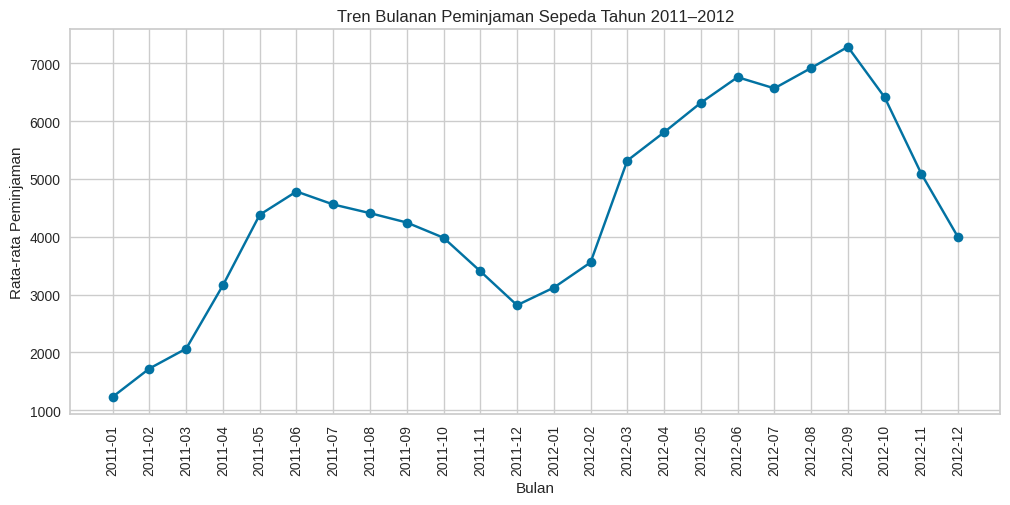

In [91]:
df['month'] = df['dteday'].dt.to_period('M')

monthly_trend = df.groupby('month')['cnt'].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_trend.index.astype(str), monthly_trend.values, marker='o')
plt.xticks(rotation=90)
plt.title('Tren Bulanan Peminjaman Sepeda Tahun 2011–2012')
plt.xlabel('Bulan')
plt.ylabel('Rata-rata Peminjaman')
plt.show()

**Insight:**

Jumlah peminjaman sepeda menunjukkan tren yang meningkat dari tahun 2011 ke 2012 dengan pola yang cukup jelas dipengaruhi oleh musim. Pada tahun 2011, jumlah peminjaman masih relatif rendah di awal tahun, kemudian meningkat secara bertahap hingga mencapai puncak sekitar pertengahan tahun, sebelum kembali menurun menjelang akhir tahun. Sementara itu, pada tahun 2012 terlihat peningkatan yang lebih signifikan dibandingkan 2011, dengan lonjakan peminjaman mulai awal hingga pertengahan tahun dan mencapai puncak tertinggi pada sekitar bulan September, sebelum kembali menurun di akhir tahun. Pola ini menunjukkan adanya pengaruh musim terhadap penggunaan sepeda, di mana peminjaman cenderung lebih tinggi pada bulan-bulan dengan kondisi cuaca yang lebih mendukung pada suhu hanggat ke panas, dan menurun pada bulan yang lebih dingin.

## Conclusion

Berdasarkan hasil analisis data peminjaman sepeda selama periode 2011–2012, dapat disimpulkan beberapa hal sebagai berikut:
- Terdapat perbedaan rata-rata jumlah peminjaman sepeda antara hari kerja dan akhir pekan, namun pola tersebut berubah dari tahun ke tahun. Pada tahun 2011, perbedaan jumlah peminjaman antara hari kerja yaitu sekitar 3425,06 dan akhir pekan sekitar 3363,82, perbedaanya relatif kecil, menunjukkan pola penggunaan yang masih seimbang. Namun pada tahun 2012, terjadi peningkatan signifikan pada kedua kategori, dengan hari kerja yaitu sekitar 5744,58 lebih tinggi dibandingkan akhir pekan sekitar 5288,19. Hal ini menunjukkan bahwa sepeda semakin banyak digunakan sebagai moda transportasi harian, terutama untuk aktivitas rutin seperti bekerja atau sekolah.
- Suhu memiliki hubungan positif yang cukup kuat terhadap jumlah peminjaman sepeda pada kedua tahun, dengan korelasi sebesar 0,77 pada tahun 2011 dan 0,71 pada tahun 2012. Hal ini menunjukkan bahwa semakin tinggi suhu, semakin meningkat jumlah peminjaman sepeda. Sebaliknya, kelembapan memiliki pengaruh yang sangat lemah terhadap peminjaman, baik pada tahun 2011 maupun 2012, sehingga tidak menjadi faktor utama yang memengaruhi permintaan sepeda.
- Terdapat tren peningkatan jumlah peminjaman sepeda dari tahun 2011 ke 2012, dengan pola musiman yang cukup jelas. Peminjaman cenderung meningkat pada pertengahan tahun dan mencapai puncak pada bulan-bulan dengan kondisi cuaca hangat, kemudian menurun pada akhir tahun. Hal ini menunjukkan bahwa selain faktor waktu, musim dan kondisi cuaca juga berperan dalam memengaruhi tingkat penggunaan sepeda.